# Importing Libraries

In [ ]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline

from sklearn.ensemble import AdaBoostClassifier

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler
from imblearn.over_sampling import SMOTE
from imblearn.ensemble import BalancedRandomForestClassifier
import xgboost as xgb
from imblearn.pipeline import Pipeline

from collections import Counter

# Set pandas to display all columns
pd.set_option('display.max_columns', None)

# Uploading Dataset

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving student_dropout.csv to student_dropout.csv


# Loading data and basic overview

In [ ]:
df = pd.read_csv("student_dropout.csv")

df.head()

,School,Gender,Age,Address,Family_Size,Parental_Status,Mother_Education,Father_Education,Mother_Job,Father_Job,Reason_for_Choosing_School,Guardian,Travel_Time,Study_Time,Number_of_Failures,School_Support,Family_Support,Extra_Paid_Class,Extra_Curricular_Activities,Attended_Nursery,Wants_Higher_Education,Internet_Access,In_Relationship,Family_Relationship,Free_Time,Going_Out,Weekend_Alcohol_Consumption,Weekday_Alcohol_Consumption,Health_Status,Number_of_Absences,Grade_1,Grade_2,Final_Grade,Dropped_Out
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,course,mother,2,2,0,yes,no,no,no,yes,yes,no,no,4,3,4,1,1,3,4,0,11,11,False
1,GP,F,17,U,GT3,T,1,1,at_home,other,course,father,1,2,0,no,yes,no,no,no,yes,yes,no,5,3,3,1,1,3,2,9,11,11,False
2,GP,F,15,U,LE3,T,1,1,at_home,other,other,mother,1,2,0,yes,no,no,no,yes,yes,yes,no,4,3,2,2,3,3,6,12,13,12,False
3,GP,F,15,U,GT3,T,4,2,health,services,home,mother,1,3,0,no,yes,no,yes,yes,yes,yes,yes,3,2,2,1,1,5,0,14,14,14,False
4,GP,F,16,U,GT3,T,3,3,other,other,home,father,1,2,0,no,yes,no,no,yes,yes,no,no,4,3,2,1,2,5,0,11,13,13,False


In [ ]:
df.shape

(649, 34)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 34 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   School                       649 non-null    object
 1   Gender                       649 non-null    object
 2   Age                          649 non-null    int64 
 3   Address                      649 non-null    object
 4   Family_Size                  649 non-null    object
 5   Parental_Status              649 non-null    object
 6   Mother_Education             649 non-null    int64 
 7   Father_Education             649 non-null    int64 
 8   Mother_Job                   649 non-null    object
 9   Father_Job                   649 non-null    object
 10  Reason_for_Choosing_School   649 non-null    object
 11  Guardian                     649 non-null    object
 12  Travel_Time                  649 non-null    int64 
 13  Study_Time                   649 no

# Teenager data: age --> [15, 19]

In [ ]:
# Shape of original data

df.shape

(649, 34)

In [ ]:
# Shape of the data where age belongs in between 15 and 19
df[(df["Age"] >= 15) & (df["Age"] <= 19)].shape

(640, 34)

In [ ]:
df = df[(df["Age"] >= 15) & (df["Age"] <= 19)]

df.head()

,School,Gender,Age,Address,Family_Size,Parental_Status,Mother_Education,Father_Education,Mother_Job,Father_Job,Reason_for_Choosing_School,Guardian,Travel_Time,Study_Time,Number_of_Failures,School_Support,Family_Support,Extra_Paid_Class,Extra_Curricular_Activities,Attended_Nursery,Wants_Higher_Education,Internet_Access,In_Relationship,Family_Relationship,Free_Time,Going_Out,Weekend_Alcohol_Consumption,Weekday_Alcohol_Consumption,Health_Status,Number_of_Absences,Grade_1,Grade_2,Final_Grade,Dropped_Out
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,course,mother,2,2,0,yes,no,no,no,yes,yes,no,no,4,3,4,1,1,3,4,0,11,11,False
1,GP,F,17,U,GT3,T,1,1,at_home,other,course,father,1,2,0,no,yes,no,no,no,yes,yes,no,5,3,3,1,1,3,2,9,11,11,False
2,GP,F,15,U,LE3,T,1,1,at_home,other,other,mother,1,2,0,yes,no,no,no,yes,yes,yes,no,4,3,2,2,3,3,6,12,13,12,False
3,GP,F,15,U,GT3,T,4,2,health,services,home,mother,1,3,0,no,yes,no,yes,yes,yes,yes,yes,3,2,2,1,1,5,0,14,14,14,False
4,GP,F,16,U,GT3,T,3,3,other,other,home,father,1,2,0,no,yes,no,no,yes,yes,no,no,4,3,2,1,2,5,0,11,13,13,False


# Stripping string values in object column

In [ ]:
# Columns with string (object) datatype

string_columns = list(df.select_dtypes(include = ["object"]).columns)

print(string_columns)

['School', 'Gender', 'Address', 'Family_Size', 'Parental_Status', 'Mother_Job', 'Father_Job', 'Reason_for_Choosing_School', 'Guardian', 'School_Support', 'Family_Support', 'Extra_Paid_Class', 'Extra_Curricular_Activities', 'Attended_Nursery', 'Wants_Higher_Education', 'Internet_Access', 'In_Relationship']


In [ ]:
# Function to strip string values

def strip_strings(string):
  return string.strip()

In [ ]:
# Apply strip_strings function to each column present in 'string_columns'

for str_col in string_columns:
  df[str_col] = df[str_col].apply(strip_strings)

df.head()

,School,Gender,Age,Address,Family_Size,Parental_Status,Mother_Education,Father_Education,Mother_Job,Father_Job,Reason_for_Choosing_School,Guardian,Travel_Time,Study_Time,Number_of_Failures,School_Support,Family_Support,Extra_Paid_Class,Extra_Curricular_Activities,Attended_Nursery,Wants_Higher_Education,Internet_Access,In_Relationship,Family_Relationship,Free_Time,Going_Out,Weekend_Alcohol_Consumption,Weekday_Alcohol_Consumption,Health_Status,Number_of_Absences,Grade_1,Grade_2,Final_Grade,Dropped_Out
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,course,mother,2,2,0,yes,no,no,no,yes,yes,no,no,4,3,4,1,1,3,4,0,11,11,False
1,GP,F,17,U,GT3,T,1,1,at_home,other,course,father,1,2,0,no,yes,no,no,no,yes,yes,no,5,3,3,1,1,3,2,9,11,11,False
2,GP,F,15,U,LE3,T,1,1,at_home,other,other,mother,1,2,0,yes,no,no,no,yes,yes,yes,no,4,3,2,2,3,3,6,12,13,12,False
3,GP,F,15,U,GT3,T,4,2,health,services,home,mother,1,3,0,no,yes,no,yes,yes,yes,yes,yes,3,2,2,1,1,5,0,14,14,14,False
4,GP,F,16,U,GT3,T,3,3,other,other,home,father,1,2,0,no,yes,no,no,yes,yes,no,no,4,3,2,1,2,5,0,11,13,13,False


# Missing Values

In [ ]:
# No missing values present

df.isna().sum()

,0
School,0
Gender,0
Age,0
Address,0
Family_Size,0
Parental_Status,0
Mother_Education,0
Father_Education,0
Mother_Job,0
Father_Job,0


In [ ]:
# No null values
df.isnull().sum()

,0
School,0
Gender,0
Age,0
Address,0
Family_Size,0
Parental_Status,0
Mother_Education,0
Father_Education,0
Mother_Job,0
Father_Job,0


# Duplicates

In [ ]:
# No rows has been duplicated

df.duplicated().sum()

np.int64(0)

# Download the file for EDA

In [ ]:
df.head()

,School,Gender,Age,Address,Family_Size,Parental_Status,Mother_Education,Father_Education,Mother_Job,Father_Job,Reason_for_Choosing_School,Guardian,Travel_Time,Study_Time,Number_of_Failures,School_Support,Family_Support,Extra_Paid_Class,Extra_Curricular_Activities,Attended_Nursery,Wants_Higher_Education,Internet_Access,In_Relationship,Family_Relationship,Free_Time,Going_Out,Weekend_Alcohol_Consumption,Weekday_Alcohol_Consumption,Health_Status,Number_of_Absences,Grade_1,Grade_2,Final_Grade,Dropped_Out
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,course,mother,2,2,0,yes,no,no,no,yes,yes,no,no,4,3,4,1,1,3,4,0,11,11,False
1,GP,F,17,U,GT3,T,1,1,at_home,other,course,father,1,2,0,no,yes,no,no,no,yes,yes,no,5,3,3,1,1,3,2,9,11,11,False
2,GP,F,15,U,LE3,T,1,1,at_home,other,other,mother,1,2,0,yes,no,no,no,yes,yes,yes,no,4,3,2,2,3,3,6,12,13,12,False
3,GP,F,15,U,GT3,T,4,2,health,services,home,mother,1,3,0,no,yes,no,yes,yes,yes,yes,yes,3,2,2,1,1,5,0,14,14,14,False
4,GP,F,16,U,GT3,T,3,3,other,other,home,father,1,2,0,no,yes,no,no,yes,yes,no,no,4,3,2,1,2,5,0,11,13,13,False


In [ ]:
# Convert to csv and save locally

df.to_csv("student_dropout_for_eda.csv", index=False)

# Value counts on each string column

In [ ]:
for col in string_columns:
    print(f"\n--- Value counts for column: {col} ---")
    print(df[col].value_counts())


--- Value counts for column: School ---
School
GP    416
MS    224
Name: count, dtype: int64

--- Value counts for column: Gender ---
Gender
F    378
M    262
Name: count, dtype: int64

--- Value counts for column: Address ---
Address
U    447
R    193
Name: count, dtype: int64

--- Value counts for column: Family_Size ---
Family_Size
GT3    450
LE3    190
Name: count, dtype: int64

--- Value counts for column: Parental_Status ---
Parental_Status
T    561
A     79
Name: count, dtype: int64

--- Value counts for column: Mother_Job ---
Mother_Job
other       253
services    134
at_home     133
teacher      72
health       48
Name: count, dtype: int64

--- Value counts for column: Father_Job ---
Father_Job
other       360
services    179
at_home      42
teacher      36
health       23
Name: count, dtype: int64

--- Value counts for column: Reason_for_Choosing_School ---
Reason_for_Choosing_School
course        281
home          149
reputation    140
other          70
Name: count, dtype: 

# Encoding

## One-Hot Encoding : Categorical Columns with no order or rank in their categories

In [ ]:
OHE_cols = ["School", "Gender", "Address", "Family_Size", "Parental_Status", "Mother_Job", "Father_Job", "Reason_for_Choosing_School", "Guardian", "School_Support", "Family_Support", "Extra_Paid_Class", "Extra_Curricular_Activities", "Attended_Nursery", "Wants_Higher_Education", "Internet_Access", "In_Relationship"]

In [ ]:
# drop = 'first' avoids dummy variable trap

one_hot_encoder = OneHotEncoder(drop = "first", sparse_output = False)

In [ ]:
one_hot_encoded_array = one_hot_encoder.fit_transform(df[OHE_cols])

one_hot_encoded_array

array([[0., 0., 1., ..., 1., 0., 0.],
       [0., 0., 1., ..., 1., 1., 0.],
       [0., 0., 1., ..., 1., 1., 0.],
       ...,
       [1., 0., 1., ..., 1., 0., 0.],
       [1., 1., 1., ..., 1., 1., 0.],
       [1., 1., 0., ..., 1., 1., 0.]])

In [ ]:
one_hot_encoded_df = pd.DataFrame(one_hot_encoded_array, columns = one_hot_encoder.get_feature_names_out(OHE_cols))

one_hot_encoded_df

,School_MS,Gender_M,Address_U,Family_Size_LE3,Parental_Status_T,Mother_Job_health,Mother_Job_other,Mother_Job_services,Mother_Job_teacher,Father_Job_health,Father_Job_other,Father_Job_services,Father_Job_teacher,Reason_for_Choosing_School_home,Reason_for_Choosing_School_other,Reason_for_Choosing_School_reputation,Guardian_mother,Guardian_other,School_Support_yes,Family_Support_yes,Extra_Paid_Class_yes,Extra_Curricular_Activities_yes,Attended_Nursery_yes,Wants_Higher_Education_yes,Internet_Access_yes,In_Relationship_yes
0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
1,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0
2,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0
3,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0
4,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
635,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0
636,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0
637,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0
638,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0


## Add other numerical columns to the one hot encoded df

In [ ]:
numeric_columns = list(df.select_dtypes(include = ["int"]).columns)

numeric_columns

['Age',
 'Mother_Education',
 'Father_Education',
 'Travel_Time',
 'Study_Time',
 'Number_of_Failures',
 'Family_Relationship',
 'Free_Time',
 'Going_Out',
 'Weekend_Alcohol_Consumption',
 'Weekday_Alcohol_Consumption',
 'Health_Status',
 'Number_of_Absences',
 'Grade_1',
 'Grade_2',
 'Final_Grade']

In [ ]:
one_hot_encoded_df[numeric_columns] = df[numeric_columns]

one_hot_encoded_df.head()

,School_MS,Gender_M,Address_U,Family_Size_LE3,Parental_Status_T,Mother_Job_health,Mother_Job_other,Mother_Job_services,Mother_Job_teacher,Father_Job_health,Father_Job_other,Father_Job_services,Father_Job_teacher,Reason_for_Choosing_School_home,Reason_for_Choosing_School_other,Reason_for_Choosing_School_reputation,Guardian_mother,Guardian_other,School_Support_yes,Family_Support_yes,Extra_Paid_Class_yes,Extra_Curricular_Activities_yes,Attended_Nursery_yes,Wants_Higher_Education_yes,Internet_Access_yes,In_Relationship_yes,Age,Mother_Education,Father_Education,Travel_Time,Study_Time,Number_of_Failures,Family_Relationship,Free_Time,Going_Out,Weekend_Alcohol_Consumption,Weekday_Alcohol_Consumption,Health_Status,Number_of_Absences,Grade_1,Grade_2,Final_Grade
0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,18.0,4.0,4.0,2.0,2.0,0.0,4.0,3.0,4.0,1.0,1.0,3.0,4.0,0.0,11.0,11.0
1,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,17.0,1.0,1.0,1.0,2.0,0.0,5.0,3.0,3.0,1.0,1.0,3.0,2.0,9.0,11.0,11.0
2,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,15.0,1.0,1.0,1.0,2.0,0.0,4.0,3.0,2.0,2.0,3.0,3.0,6.0,12.0,13.0,12.0
3,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,15.0,4.0,2.0,1.0,3.0,0.0,3.0,2.0,2.0,1.0,1.0,5.0,0.0,14.0,14.0,14.0
4,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,16.0,3.0,3.0,1.0,2.0,0.0,4.0,3.0,2.0,1.0,2.0,5.0,0.0,11.0,13.0,13.0


## Label Encoding: for output categorical column

In [ ]:
label_encoder = LabelEncoder()

In [ ]:
one_hot_encoded_df["Target"] = label_encoder.fit_transform(df["Dropped_Out"])

one_hot_encoded_df.head()

,School_MS,Gender_M,Address_U,Family_Size_LE3,Parental_Status_T,Mother_Job_health,Mother_Job_other,Mother_Job_services,Mother_Job_teacher,Father_Job_health,Father_Job_other,Father_Job_services,Father_Job_teacher,Reason_for_Choosing_School_home,Reason_for_Choosing_School_other,Reason_for_Choosing_School_reputation,Guardian_mother,Guardian_other,School_Support_yes,Family_Support_yes,Extra_Paid_Class_yes,Extra_Curricular_Activities_yes,Attended_Nursery_yes,Wants_Higher_Education_yes,Internet_Access_yes,In_Relationship_yes,Age,Mother_Education,Father_Education,Travel_Time,Study_Time,Number_of_Failures,Family_Relationship,Free_Time,Going_Out,Weekend_Alcohol_Consumption,Weekday_Alcohol_Consumption,Health_Status,Number_of_Absences,Grade_1,Grade_2,Final_Grade,Target
0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,18.0,4.0,4.0,2.0,2.0,0.0,4.0,3.0,4.0,1.0,1.0,3.0,4.0,0.0,11.0,11.0,0
1,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,17.0,1.0,1.0,1.0,2.0,0.0,5.0,3.0,3.0,1.0,1.0,3.0,2.0,9.0,11.0,11.0,0
2,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,15.0,1.0,1.0,1.0,2.0,0.0,4.0,3.0,2.0,2.0,3.0,3.0,6.0,12.0,13.0,12.0,0
3,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,15.0,4.0,2.0,1.0,3.0,0.0,3.0,2.0,2.0,1.0,1.0,5.0,0.0,14.0,14.0,14.0,0
4,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,16.0,3.0,3.0,1.0,2.0,0.0,4.0,3.0,2.0,1.0,2.0,5.0,0.0,11.0,13.0,13.0,0


In [ ]:
one_hot_encoded_df["Target"].head()

,Target
0,0
1,0
2,0
3,0
4,0


In [ ]:
one_hot_encoded_df["Target"].value_counts()

,count
Target,
0,541
1,99


In [ ]:
df["Dropped_Out"].value_counts()

,count
Dropped_Out,
False,541
True,99


# Extracting X and y and then spliting it

In [ ]:
one_hot_encoded_df.head()

,School_MS,Gender_M,Address_U,Family_Size_LE3,Parental_Status_T,Mother_Job_health,Mother_Job_other,Mother_Job_services,Mother_Job_teacher,Father_Job_health,Father_Job_other,Father_Job_services,Father_Job_teacher,Reason_for_Choosing_School_home,Reason_for_Choosing_School_other,Reason_for_Choosing_School_reputation,Guardian_mother,Guardian_other,School_Support_yes,Family_Support_yes,Extra_Paid_Class_yes,Extra_Curricular_Activities_yes,Attended_Nursery_yes,Wants_Higher_Education_yes,Internet_Access_yes,In_Relationship_yes,Age,Mother_Education,Father_Education,Travel_Time,Study_Time,Number_of_Failures,Family_Relationship,Free_Time,Going_Out,Weekend_Alcohol_Consumption,Weekday_Alcohol_Consumption,Health_Status,Number_of_Absences,Grade_1,Grade_2,Final_Grade,Target
0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,18.0,4.0,4.0,2.0,2.0,0.0,4.0,3.0,4.0,1.0,1.0,3.0,4.0,0.0,11.0,11.0,0
1,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,17.0,1.0,1.0,1.0,2.0,0.0,5.0,3.0,3.0,1.0,1.0,3.0,2.0,9.0,11.0,11.0,0
2,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,15.0,1.0,1.0,1.0,2.0,0.0,4.0,3.0,2.0,2.0,3.0,3.0,6.0,12.0,13.0,12.0,0
3,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,15.0,4.0,2.0,1.0,3.0,0.0,3.0,2.0,2.0,1.0,1.0,5.0,0.0,14.0,14.0,14.0,0
4,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,16.0,3.0,3.0,1.0,2.0,0.0,4.0,3.0,2.0,1.0,2.0,5.0,0.0,11.0,13.0,13.0,0


In [ ]:
one_hot_encoded_df.isna().sum()

,0
School_MS,0
Gender_M,0
Address_U,0
Family_Size_LE3,0
Parental_Status_T,0
Mother_Job_health,0
Mother_Job_other,0
Mother_Job_services,0
Mother_Job_teacher,0
Father_Job_health,0


In [ ]:
one_hot_encoded_df[one_hot_encoded_df["Age"].isna()].shape

(9, 43)

In [ ]:
one_hot_encoded_df = one_hot_encoded_df.dropna()

one_hot_encoded_df.isna().sum()

,0
School_MS,0
Gender_M,0
Address_U,0
Family_Size_LE3,0
Parental_Status_T,0
Mother_Job_health,0
Mother_Job_other,0
Mother_Job_services,0
Mother_Job_teacher,0
Father_Job_health,0


In [ ]:
ml_model_df = one_hot_encoded_df

In [ ]:
ml_model_df.to_csv("ml_model_df.csv")

In [ ]:
ml_model_df.isna().sum()

,0
School_MS,0
Gender_M,0
Address_U,0
Family_Size_LE3,0
Parental_Status_T,0
Mother_Job_health,0
Mother_Job_other,0
Mother_Job_services,0
Mother_Job_teacher,0
Father_Job_health,0


In [ ]:
X = ml_model_df[list(ml_model_df.columns)[:-1]]
y = ml_model_df["Target"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [ ]:
X.head()

,School_MS,Gender_M,Address_U,Family_Size_LE3,Parental_Status_T,Mother_Job_health,Mother_Job_other,Mother_Job_services,Mother_Job_teacher,Father_Job_health,Father_Job_other,Father_Job_services,Father_Job_teacher,Reason_for_Choosing_School_home,Reason_for_Choosing_School_other,Reason_for_Choosing_School_reputation,Guardian_mother,Guardian_other,School_Support_yes,Family_Support_yes,Extra_Paid_Class_yes,Extra_Curricular_Activities_yes,Attended_Nursery_yes,Wants_Higher_Education_yes,Internet_Access_yes,In_Relationship_yes,Age,Mother_Education,Father_Education,Travel_Time,Study_Time,Number_of_Failures,Family_Relationship,Free_Time,Going_Out,Weekend_Alcohol_Consumption,Weekday_Alcohol_Consumption,Health_Status,Number_of_Absences,Grade_1,Grade_2,Final_Grade
0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,18.0,4.0,4.0,2.0,2.0,0.0,4.0,3.0,4.0,1.0,1.0,3.0,4.0,0.0,11.0,11.0
1,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,17.0,1.0,1.0,1.0,2.0,0.0,5.0,3.0,3.0,1.0,1.0,3.0,2.0,9.0,11.0,11.0
2,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,15.0,1.0,1.0,1.0,2.0,0.0,4.0,3.0,2.0,2.0,3.0,3.0,6.0,12.0,13.0,12.0
3,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,15.0,4.0,2.0,1.0,3.0,0.0,3.0,2.0,2.0,1.0,1.0,5.0,0.0,14.0,14.0,14.0
4,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,16.0,3.0,3.0,1.0,2.0,0.0,4.0,3.0,2.0,1.0,2.0,5.0,0.0,11.0,13.0,13.0


In [ ]:
y.head()

,Target
0,0
1,0
2,0
3,0
4,0


# Logistic Regression

In [ ]:
model = LogisticRegression()

In [ ]:
model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8582677165354331

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.98      0.92       110
           1       0.33      0.06      0.10        17

    accuracy                           0.86       127
   macro avg       0.60      0.52      0.51       127
weighted avg       0.80      0.86      0.81       127



## Logistic Regression with StandardScalar Pipelined

StandardScalar --> used to scale the values at same point

In [ ]:
lr_model_pipe = make_pipeline(StandardScaler(), LogisticRegression())

In [ ]:
lr_model_pipe.fit(X_train, y_train)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('logisticregression', LogisticRegression())])

In [ ]:
y_pred_lr_model_pipe = lr_model_pipe.predict(X_test)

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred_lr_model_pipe))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr_model_pipe))

Accuracy: 0.8582677165354331

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.98      0.92       110
           1       0.33      0.06      0.10        17

    accuracy                           0.86       127
   macro avg       0.60      0.52      0.51       127
weighted avg       0.80      0.86      0.81       127



## Insights:

*   LogisticRegression (without StandardScalar) --> 85% accuracy
*   LogisticRegression (with Pipelined StandardScalar) --> 85% accuracy
*   Accuracy and classification report have not changed.


# Class Imbalance

In [ ]:
ml_model_df["Target"].value_counts()

,count
Target,
0,535
1,96


Observation --> Class Imbalance might be the problem for lower accuracy and classification report.

# Handling Class Imbalance and then applying algorithms

## Random UnderSampling

In [ ]:
print("Original train distribution:- ", Counter(y_train))
print("Original test distribution:- ", Counter(y_test))

Original train distribution:-  Counter({0: 425, 1: 79})
Original test distribution:-  Counter({0: 110, 1: 17})


In [ ]:
# Random Under-Sampling on training dataset only

rus = RandomUnderSampler(random_state = 42)

X_train_under, y_train_under = rus.fit_resample(X_train, y_train)

In [ ]:
print("New train distribution:- ", Counter(y_train_under))

New train distribution:-  Counter({0: 79, 1: 79})


In [ ]:
# Training model using X_train_under and y_train_under

model = LogisticRegression()

model.fit(X_train_under, y_train_under)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [ ]:
# Making predictions

y_pred_rus = model.predict(X_test)

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred_rus))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rus))

Accuracy: 0.7322834645669292

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.76      0.83       110
           1       0.26      0.53      0.35        17

    accuracy                           0.73       127
   macro avg       0.59      0.65      0.59       127
weighted avg       0.83      0.73      0.77       127



### Random UnderSampling with Pipelined StandardScalar

In [ ]:
pipe_rus = Pipeline([
    ('scaler', StandardScaler()),
    ('rus', RandomUnderSampler(random_state=42)),
    ('classifier', LogisticRegression())
])

In [ ]:
pipe_rus.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('rus', RandomUnderSampler(random_state=42)),
                ('classifier', LogisticRegression())])

In [ ]:
y_pred_rus_pipe = pipe_rus.predict(X_test)

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred_rus_pipe))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rus_pipe))

Accuracy: 0.6850393700787402

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.71      0.80       110
           1       0.22      0.53      0.31        17

    accuracy                           0.69       127
   macro avg       0.56      0.62      0.55       127
weighted avg       0.81      0.69      0.73       127



Observations:



*   Random Under-Sampling (without Pipelined StandardScalar) --> 73% accuracy and good classification report for minority class too
*   Random Under-Sampling (with Pipelined StandardScalar) --> 68% accuracy and bad classification report for minority class



## Random Over-Sampling

In [ ]:
print("Original train distribution:- ", Counter(y_train))
print("Original test distribution:- ", Counter(y_test))

Original train distribution:-  Counter({0: 425, 1: 79})
Original test distribution:-  Counter({0: 110, 1: 17})


In [ ]:
# Random Over-Sampling on training dataset only

ros = RandomOverSampler(random_state = 42)

X_train_over, y_train_over = ros.fit_resample(X_train, y_train)

In [ ]:
print("New train distribution:- ", Counter(y_train_over))

New train distribution:-  Counter({0: 425, 1: 425})


In [ ]:
# Training model using X_train_over and y_train_over

model = LogisticRegression()

model.fit(X_train_over, y_train_over)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [ ]:
# Making predictions

y_pred_ros = model.predict(X_test)

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred_ros))
print("\nClassification Report:\n", classification_report(y_test, y_pred_ros))

Accuracy: 0.8031496062992126

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.85      0.88       110
           1       0.33      0.47      0.39        17

    accuracy                           0.80       127
   macro avg       0.62      0.66      0.64       127
weighted avg       0.84      0.80      0.82       127



### Random Over-Sampling with Pipelined StandardScalar

In [ ]:
pipe_ros = Pipeline([
    ('scaler', StandardScaler()),
    ('ros', RandomOverSampler(random_state=42)),
    ('classifier', LogisticRegression())
])

In [ ]:
pipe_ros.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('ros', RandomOverSampler(random_state=42)),
                ('classifier', LogisticRegression())])

In [ ]:
y_pred_ros_pipe = pipe_ros.predict(X_test)

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred_ros_pipe))
print("\nClassification Report:\n", classification_report(y_test, y_pred_ros_pipe))

Accuracy: 0.7874015748031497

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.85      0.87       110
           1       0.29      0.41      0.34        17

    accuracy                           0.79       127
   macro avg       0.60      0.63      0.61       127
weighted avg       0.82      0.79      0.80       127



Observation:


*   Random Over-Sampling (without pipelined StandardScalar) --> 80% accuracy and better classification report for minority class too
*   Random Over-Sampling (with pipelined StandardScalar) --> 78% accuracy and bad classification report for minority class --> model not learning from minority class



## SMOTE: Synthetic Minority Over-Sampling Technique

In [ ]:
print("Original train distribution:- ", Counter(y_train))
print("Original test distribution:- ", Counter(y_test))

Original train distribution:-  Counter({0: 425, 1: 79})
Original test distribution:-  Counter({0: 110, 1: 17})


In [ ]:
# Applying SMOTE on training dataset only

smote = SMOTE(random_state = 42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [ ]:
print("New train distribution:- ", Counter(y_train_smote))

New train distribution:-  Counter({0: 425, 1: 425})


In [ ]:
# Training model using X_train_smote and y_train_smote

model = LogisticRegression()

model.fit(X_train_smote, y_train_smote)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [ ]:
# Making predictions

y_pred_smote = model.predict(X_test)

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred_smote))
print("\nClassification Report:\n", classification_report(y_test, y_pred_smote))

Accuracy: 0.7795275590551181

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.85      0.87       110
           1       0.26      0.35      0.30        17

    accuracy                           0.78       127
   macro avg       0.58      0.60      0.58       127
weighted avg       0.81      0.78      0.79       127



### SMOTE with StandardScalar and Pipeline

In [ ]:
smote_model_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('classifier', LogisticRegression())
])

In [ ]:
smote_model_pipeline.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()), ('smote', SMOTE(random_state=42)),
                ('classifier', LogisticRegression())])

In [ ]:
y_pred_smote_pipeline = smote_model_pipeline.predict(X_test)

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred_smote_pipeline))
print("\nClassification Report:\n", classification_report(y_test,y_pred_smote_pipeline))

Accuracy: 0.7952755905511811

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.86      0.88       110
           1       0.29      0.35      0.32        17

    accuracy                           0.80       127
   macro avg       0.59      0.61      0.60       127
weighted avg       0.81      0.80      0.80       127



## Ensemble Learning

In [ ]:
print("Original train distribution:- ", Counter(y_train))
print("Original test distribution:- ", Counter(y_test))

Original train distribution:-  Counter({0: 425, 1: 79})
Original test distribution:-  Counter({0: 110, 1: 17})


In [ ]:
# Applying BalancedRandomForestClassifier on training dataset only

brf = BalancedRandomForestClassifier(random_state = 42)
brf.fit(X_train, y_train)

BalancedRandomForestClassifier(random_state=42)

In [ ]:
# Making predictions

y_pred_brf = brf.predict(X_test)

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred_brf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_brf))

Accuracy: 0.7795275590551181

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.83      0.87       110
           1       0.30      0.47      0.36        17

    accuracy                           0.78       127
   macro avg       0.60      0.65      0.62       127
weighted avg       0.83      0.78      0.80       127



### Ensemble Learning with StandardScalar and Pipeline

In [ ]:
ensemble_model = make_pipeline(StandardScaler(), BalancedRandomForestClassifier(random_state = 42))

In [ ]:
ensemble_model.fit(X_train, y_train)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('balancedrandomforestclassifier',
                 BalancedRandomForestClassifier(random_state=42))])

In [ ]:
y_pred_ensemble = ensemble_model.predict(X_test)

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred_ensemble))
print("\nClassification Report:\n", classification_report(y_test, y_pred_ensemble))

Accuracy: 0.7795275590551181

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.83      0.87       110
           1       0.30      0.47      0.36        17

    accuracy                           0.78       127
   macro avg       0.60      0.65      0.62       127
weighted avg       0.83      0.78      0.80       127



## Cost Sensitive Learning

1 : 10, 0 : 7  -->  87 %

1 : 11, 0 : 7  -->  83 %

1 : 12, 0 : 7  -->  83 %

1 : 13, 0 : 7  -->  87 %

1 : 10, 0 : 8  -->  85 %

In [ ]:
# Training model by assigning updated class weights on X_train_weight and y_train_weight

model = LogisticRegression(class_weight = {1 : 10, 0 : 8}, solver = "liblinear")

model.fit(X_train, y_train)

LogisticRegression(class_weight={0: 8, 1: 10}, solver='liblinear')

In [ ]:
# Making predictions

y_pred = model.predict(X_test)

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8503937007874016

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.95      0.92       110
           1       0.38      0.18      0.24        17

    accuracy                           0.85       127
   macro avg       0.63      0.57      0.58       127
weighted avg       0.81      0.85      0.83       127



### Cost Sensative Learning with Pipelined StandardScalar

1 : 8, 0: 2  -->  81 %

1 : 9, 0: 2  -->  80 %

1 : 10, 0: 2  -->  77 %

1 : 10, 0: 4  -->  81 %

1 : 10, 0: 3  -->  81 %

1 : 10, 0: 5  -->  82 %

1 : 10, 0: 6  -->  83 %

1 : 10, 0: 7  -->  81 %

In [ ]:
lr_cost_model_pipe = make_pipeline(StandardScaler(), LogisticRegression(class_weight = {1 : 10, 0 : 7}, solver = "liblinear"))

In [ ]:
lr_cost_model_pipe.fit(X_train, y_train)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('logisticregression',
                 LogisticRegression(class_weight={0: 7, 1: 10},
                                    solver='liblinear'))])

In [ ]:
y_pred_lr_cost_model_pipe = lr_cost_model_pipe.predict(X_test)

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred_lr_cost_model_pipe))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr_cost_model_pipe))

Accuracy: 0.84251968503937

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.95      0.91       110
           1       0.33      0.18      0.23        17

    accuracy                           0.84       127
   macro avg       0.61      0.56      0.57       127
weighted avg       0.81      0.84      0.82       127



# AdaBoostClassifier

In [ ]:
ada_model_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('classifier', AdaBoostClassifier(n_estimators = 150, learning_rate = 0.1, random_state = 42))
])

In [ ]:
ada_model_pipe.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()), ('smote', SMOTE(random_state=42)),
                ('classifier',
                 AdaBoostClassifier(learning_rate=0.1, n_estimators=150,
                                    random_state=42))])

In [ ]:
y_pred_ada_model_pipe = ada_model_pipe.predict(X_test)

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred_ada_model_pipe))
print("\nClassification Report:\n", classification_report(y_test, y_pred_ada_model_pipe))

Accuracy: 0.7795275590551181

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.86      0.87       110
           1       0.21      0.24      0.22        17

    accuracy                           0.78       127
   macro avg       0.55      0.55      0.55       127
weighted avg       0.79      0.78      0.78       127



# XGBoost

In [ ]:
y_train.value_counts()

,count
Target,
0,425
1,79


In [ ]:
#Calculating scale_pos_weight
count_0 = (y_train == 0).sum()   # majority
count_1 = (y_train == 1).sum()   # minority

scale_pos_weight = count_0 / count_1

In [ ]:
xg_model_pipe = make_pipeline(StandardScaler(), xgb.XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    random_state=42
)
)

In [ ]:
xg_model_pipe.fit(X_train, y_train)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('xgbclassifier',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=None, device=None,
                               early_stopping_rounds=None,
                               enable_categorical=False, eval_metric=None,
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [ ]:
y_pred_xg_pipe = xg_model_pipe.predict(X_test)

In [ ]:
print("\nAccuracy:", accuracy_score(y_test, y_pred_xg_pipe))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xg_pipe))


Accuracy: 0.905511811023622

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.97      0.95       110
           1       0.73      0.47      0.57        17

    accuracy                           0.91       127
   macro avg       0.82      0.72      0.76       127
weighted avg       0.90      0.91      0.90       127



# Saving XGBoost Algorithm for Explainability

In [ ]:
import joblib

joblib.dump(xg_model_pipe, "xg_model_pipe.pkl")

xgboost_classifier = joblib.load("xg_model_pipe.pkl")

# Installing and Importing LIME

In [ ]:
!pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 5.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=b378434f51f33907c60b0834e9f62a6efb459ea7f77d38d5bbae93b8f17cee16
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


# Explainability using LIME

References:

https://lime-ml.readthedocs.io/en/latest/lime.html#module-lime.lime_tabular

In [ ]:
import lime
from lime import lime_tabular

In [ ]:
X_train.columns

Index(['School_MS', 'Gender_M', 'Address_U', 'Family_Size_LE3',
       'Parental_Status_T', 'Mother_Job_health', 'Mother_Job_other',
       'Mother_Job_services', 'Mother_Job_teacher', 'Father_Job_health',
       'Father_Job_other', 'Father_Job_services', 'Father_Job_teacher',
       'Reason_for_Choosing_School_home', 'Reason_for_Choosing_School_other',
       'Reason_for_Choosing_School_reputation', 'Guardian_mother',
       'Guardian_other', 'School_Support_yes', 'Family_Support_yes',
       'Extra_Paid_Class_yes', 'Extra_Curricular_Activities_yes',
       'Attended_Nursery_yes', 'Wants_Higher_Education_yes',
       'Internet_Access_yes', 'In_Relationship_yes', 'Age', 'Mother_Education',
       'Father_Education', 'Travel_Time', 'Study_Time', 'Number_of_Failures',
       'Family_Relationship', 'Free_Time', 'Going_Out',
       'Weekend_Alcohol_Consumption', 'Weekday_Alcohol_Consumption',
       'Health_Status', 'Number_of_Absences', 'Grade_1', 'Grade_2',
       'Final_Grade'],
      d

In [ ]:
lime_explainer = lime_tabular.LimeTabularExplainer(training_data = np.array(X_train), feature_names = X_train.columns, class_names = ["0", "1"], mode = "classification")

In [ ]:
print("Actual value:- ", y_test.iloc[125])
print("Predicted value:- ", xgboost_classifier.predict([X_test.iloc[125]])[0])

Actual value:-  1
Predicted value:-  0


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
explaination = lime_explainer.explain_instance(data_row = X_test.iloc[125].values, predict_fn = xgboost_classifier.predict_proba, num_features = len(X_train.columns))

explaination.show_in_notebook(show_table = True)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


# Explainability using SHAP

In [ ]:
!pip install shap

In [ ]:
import shap

In [ ]:
explainer  = shap.Explainer(xg_model_pipe.predict_proba, X_train)

In [ ]:
shap_values = explainer(X_test)

PermutationExplainer explainer: 128it [00:17,  4.78it/s]


In [ ]:
print(shap_values)

.values =
array([[[-0.07380077,  0.07380077],
        [-0.03693153,  0.03693153],
        [ 0.00355871, -0.00355871],
        ...,
        [ 0.00966831, -0.00966831],
        [ 0.02818277, -0.02818277],
        [ 0.02350976, -0.02350976]],

       [[ 0.05209705, -0.05209705],
        [ 0.00493107, -0.00493107],
        [-0.00118305,  0.00118305],
        ...,
        [ 0.00096441, -0.00096441],
        [ 0.00842527, -0.00842527],
        [ 0.05107271, -0.05107271]],

       [[ 0.03920648, -0.03920648],
        [ 0.0085364 , -0.0085364 ],
        [-0.0065728 ,  0.0065728 ],
        ...,
        [ 0.0041521 , -0.0041521 ],
        [ 0.02803147, -0.02803147],
        [ 0.03691293, -0.03691293]],

       ...,

       [[ 0.05220948, -0.05220948],
        [-0.00987843,  0.00987843],
        [-0.00141136,  0.00141136],
        ...,
        [ 0.00070613, -0.00070613],
        [ 0.01241051, -0.01241051],
        [ 0.0466086 , -0.0466086 ]],

       [[-0.06463325,  0.06463325],
        [ 0.02255

In [ ]:
print(type(shap_values))

<class 'shap._explanation.Explanation'>


## Global Explaination

In [ ]:
shap_values_class1 = shap_values[..., 1]

### Feature Importance Plot

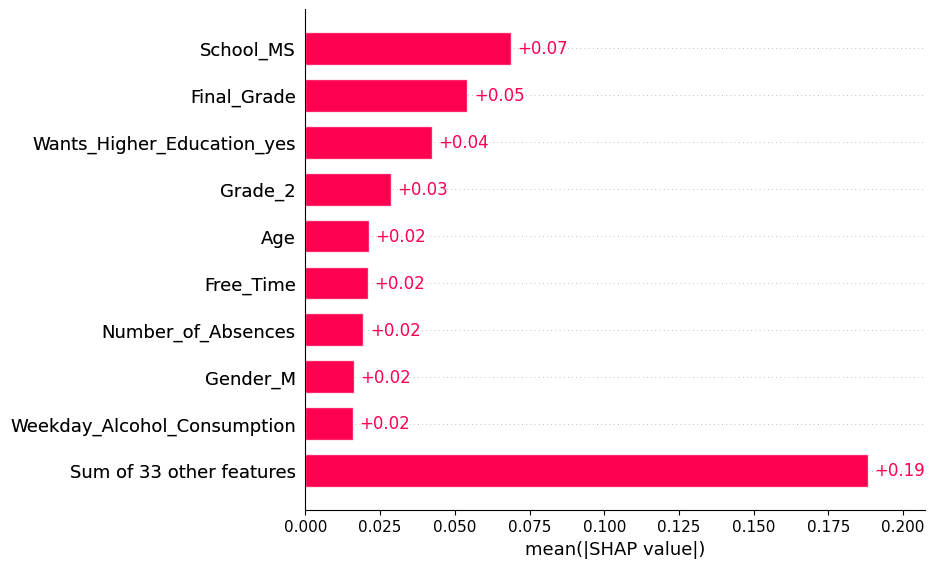

In [ ]:
shap.plots.bar(shap_values_class1)

### Summary Plot

/tmp/ipykernel_23150/1337577542.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_class1, X_test)


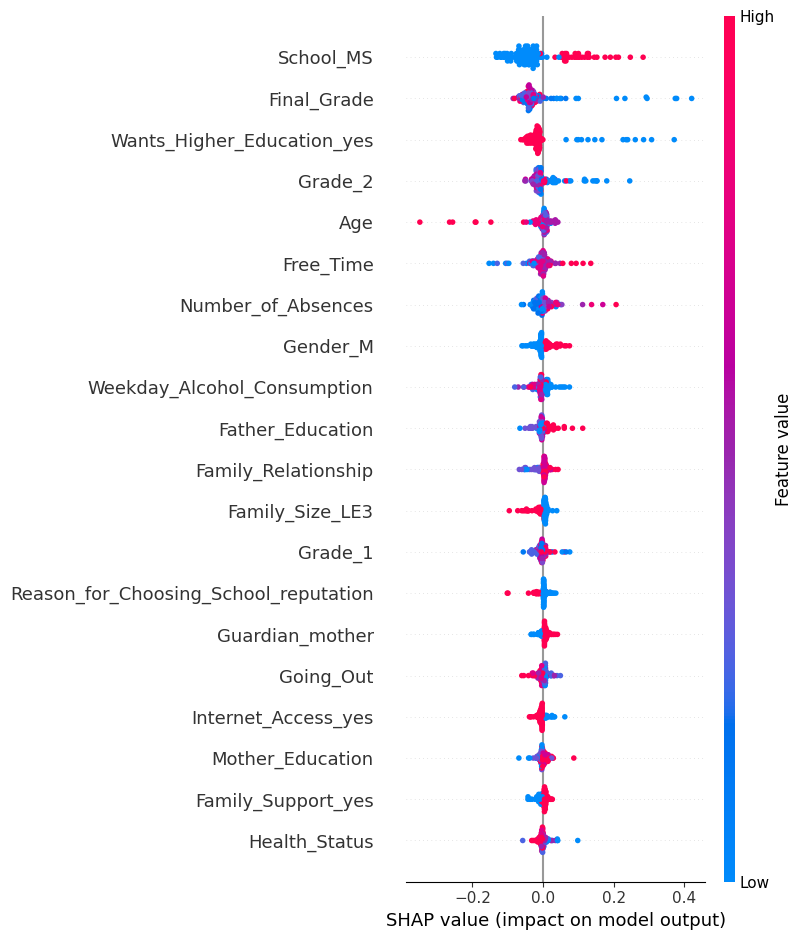

In [ ]:
shap.summary_plot(shap_values_class1, X_test)

### Local Prediction

In [ ]:
shap_values_class1

.values =
array([[ 0.07380077,  0.03693153, -0.00355871, ..., -0.00966831,
        -0.02818277, -0.02350976],
       [-0.05209705, -0.00493107,  0.00118305, ..., -0.00096441,
        -0.00842527, -0.05107271],
       [-0.03920648, -0.0085364 ,  0.0065728 , ..., -0.0041521 ,
        -0.02803147, -0.03691293],
       ...,
       [-0.05220948,  0.00987843,  0.00141136, ..., -0.00070613,
        -0.01241051, -0.0466086 ],
       [ 0.06463325, -0.02255044,  0.00186094, ..., -0.01218839,
         0.03127333, -0.00843206],
       [-0.02751258, -0.00429446, -0.00414482, ..., -0.0033892 ,
        -0.01712083, -0.04076328]])

.base_values =
array([0.15598368, 0.15598368, 0.15598368, 0.15598368, 0.15598368,
       0.15598368, 0.15598368, 0.15598368, 0.15598368, 0.15598368,
       0.15598368, 0.15598368, 0.15598368, 0.15598368, 0.15598368,
       0.15598368, 0.15598368, 0.15598368, 0.15598368, 0.15598368,
       0.15598368, 0.15598368, 0.15598368, 0.15598368, 0.15598368,
       0.15598368, 0.15598

In [ ]:
shap_values_class1[0]

.values =
array([ 7.38007721e-02,  3.69315327e-02, -3.55871212e-03, -4.13549218e-02,
       -7.61175970e-04, -7.54479471e-04, -4.11214510e-03, -6.28665913e-04,
        5.22039763e-03,  0.00000000e+00, -4.88651468e-03,  4.59421799e-03,
        0.00000000e+00, -9.91089627e-03, -2.94111462e-03,  2.86785975e-03,
        9.59641109e-03, -6.81046499e-04,  0.00000000e+00,  8.28677964e-03,
       -2.57211082e-05, -1.89706193e-02,  1.35524666e-02, -1.69496703e-02,
       -1.26301456e-02, -1.22827817e-02, -6.69392178e-03, -1.99261526e-02,
       -3.15062064e-02,  8.10112350e-03, -2.41942932e-03, -3.74115220e-03,
        1.25229681e-02, -4.53423297e-03, -1.30756922e-03, -1.76976937e-03,
       -3.77076274e-02, -3.31785891e-03, -1.30451867e-02, -9.66830709e-03,
       -2.81827696e-02, -2.35097603e-02])

.base_values =
np.float64(0.1559836823148362)

.data =
array([ 1.,  1.,  1.,  1.,  1.,  0.,  1.,  0.,  0.,  0.,  0.,  1.,  0.,
        1.,  0.,  0.,  1.,  0.,  0.,  1.,  0.,  0.,  1.,  1.,  1.,  0.

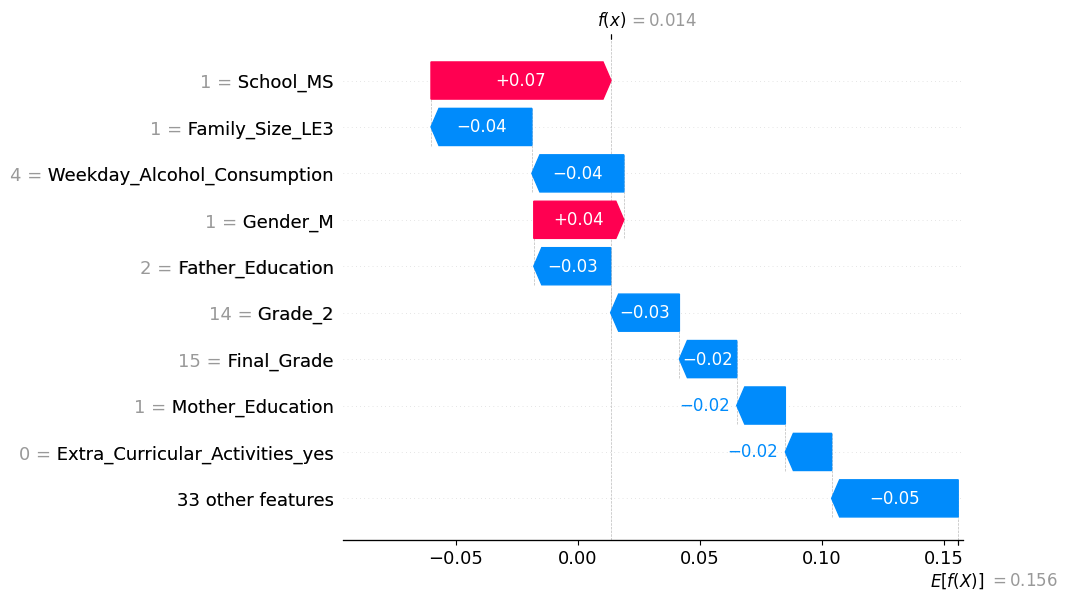

In [ ]:
shap.plots.waterfall(shap_values_class1[0])